# 06 — Phát hiện bất thường: luật ngưỡng + Isolation Forest

Hệ thống dùng phép **OR** giữa luật cứng và Isolation Forest. Luật cứng giải thích được các lỗi rõ ràng; Isolation Forest phát hiện tổ hợp đa biến hiếm. `is_pollution_episode` được giữ riêng vì ô nhiễm cao có thể là hiện tượng thật, không đồng nghĩa cảm biến lỗi.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', palette='colorblind')
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
ARTIFACTS = ROOT / 'artifacts'
report = json.loads((ARTIFACTS / 'anomaly_detection_report.json').read_text(encoding='utf-8'))
columns = [
    'split', 'timestamp', 'station_id', 'location_name', 'pm25', 'pm10',
    'pm25_change_1h', 'pm25_rolling_mean_24h', 'is_rule_anomaly',
    'is_isolation_anomaly', 'is_anomaly', 'is_pollution_episode',
    'requires_attention', 'isolation_forest_score', 'detection_source',
    'anomaly_reason'
]
results = pd.read_csv(ROOT / 'data' / 'processed' / 'anomaly_results.csv.gz', usecols=columns)
results['timestamp'] = pd.to_datetime(results['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
display(pd.Series({
    'Phương pháp': report['method'],
    'Số đặc trưng': report['feature_count'],
    'Số cây': report['isolation_forest']['n_estimators'],
    'Contamination train': report['isolation_forest']['contamination'],
    'Ngưỡng score': report['isolation_forest']['train_score_threshold'],
}).to_frame('Giá trị'))

,Giá trị
Phương pháp,threshold rules OR Isolation Forest
Số đặc trưng,17
Số cây,300
Contamination train,0.03
Ngưỡng score,-0.499417


## 1. Protocol không rò rỉ dữ liệu

- Imputer, RobustScaler, Isolation Forest và ngưỡng quantile đều chỉ fit trên train 2022–2024.
- Validation 2025 và test 2026 chỉ được transform/score.
- Không có nhãn anomaly thật, nên tỷ lệ phát hiện là diagnostic chứ không phải accuracy/precision/recall.
- Tỷ lệ Isolation Forest cao hơn 3% ngoài train có thể phản ánh distribution drift.

,rows,rule_rate_percent,isolation_rate_percent,combined_rate_percent,pollution_episode_rate_percent,requires_attention
train,167704.0,0.106,3.001,3.039,6.399,13468.0
validation,70032.0,0.678,9.656,9.814,16.807,14064.0
test,28752.0,0.250,7.773,7.881,18.120,5657.0


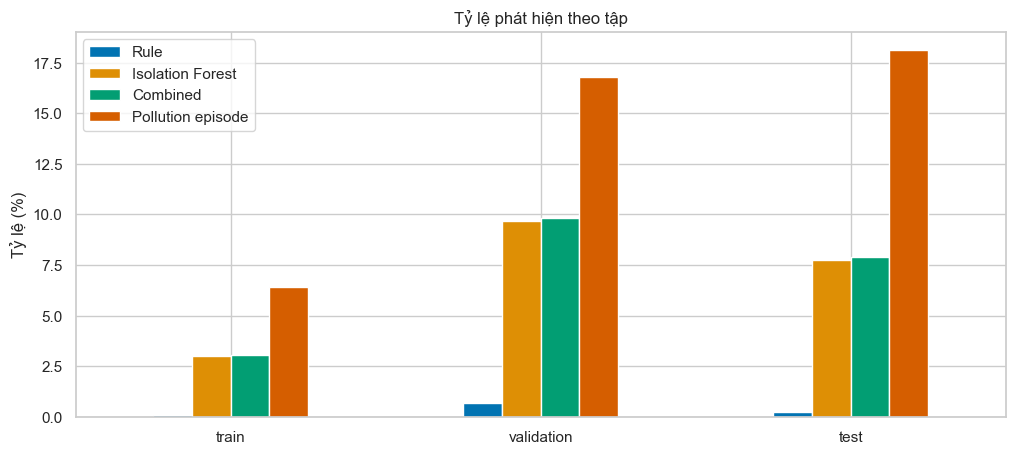

In [2]:
summary = pd.DataFrame(report['split_summary']).T
display(summary[[
    'rows', 'rule_rate_percent', 'isolation_rate_percent',
    'combined_rate_percent', 'pollution_episode_rate_percent', 'requires_attention'
]].round(3))

rates = summary[[
    'rule_rate_percent', 'isolation_rate_percent',
    'combined_rate_percent', 'pollution_episode_rate_percent'
]].rename(columns={
    'rule_rate_percent': 'Rule', 'isolation_rate_percent': 'Isolation Forest',
    'combined_rate_percent': 'Combined', 'pollution_episode_rate_percent': 'Pollution episode'
})
rates.plot(kind='bar', figsize=(12, 5))
plt.title('Tỷ lệ phát hiện theo tập')
plt.xlabel('')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.show()

## 2. Phân phối anomaly score

Score càng thấp càng bất thường. Điểm có score nhỏ hơn hoặc bằng ngưỡng học từ quantile 3% của train được Isolation Forest gắn cờ.

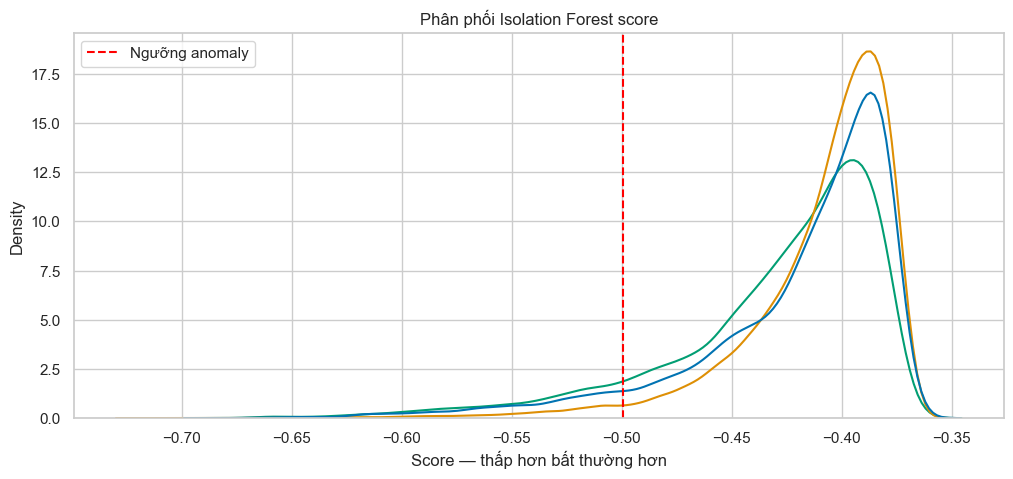

In [3]:
sample = results.groupby('split', group_keys=False).sample(n=20000, random_state=42)
fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(data=sample, x='isolation_forest_score', hue='split', common_norm=False, ax=ax)
ax.axvline(
    report['isolation_forest']['train_score_threshold'], color='red', linestyle='--',
    label='Ngưỡng anomaly'
)
ax.set(title='Phân phối Isolation Forest score', xlabel='Score — thấp hơn bất thường hơn')
ax.legend()
plt.show()

## 3. Luật nào được kích hoạt?

,rule_invalid_range,rule_cleaning_spike,rule_rapid_pm25_change,rule_flatline,rule_pm_inconsistency,rule_extreme_pm25
train,0,135,41,0,0,10
validation,0,292,113,0,0,70
test,0,35,30,0,0,8


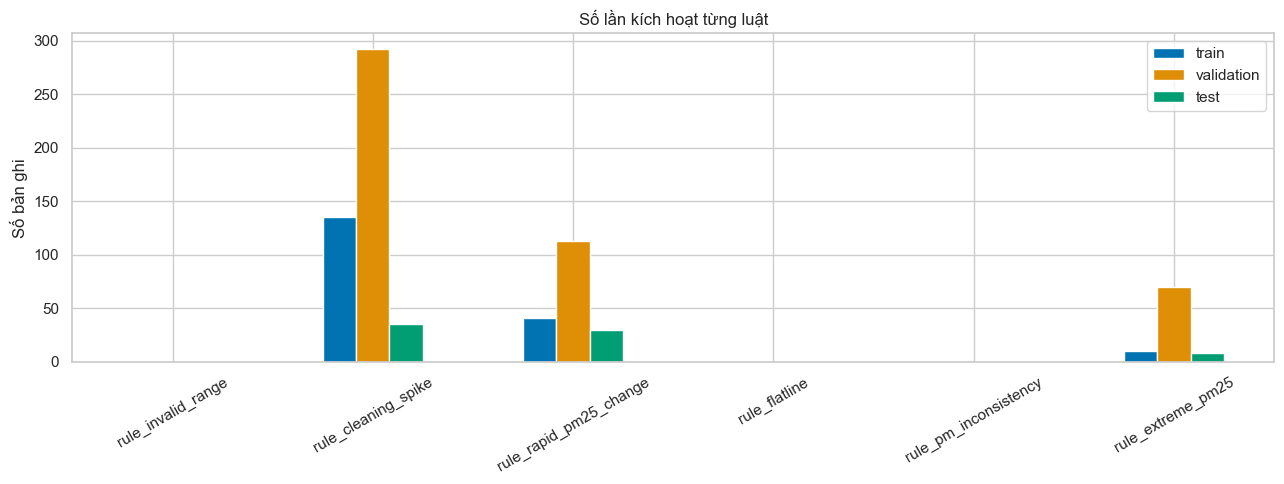

In [4]:
rule_counts = pd.DataFrame(report['rule_counts']).T
display(rule_counts)

ax = rule_counts.T.plot(kind='bar', figsize=(13, 5))
ax.set(title='Số lần kích hoạt từng luật', xlabel='', ylabel='Số bản ghi')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Bất thường và đợt ô nhiễm theo thời gian

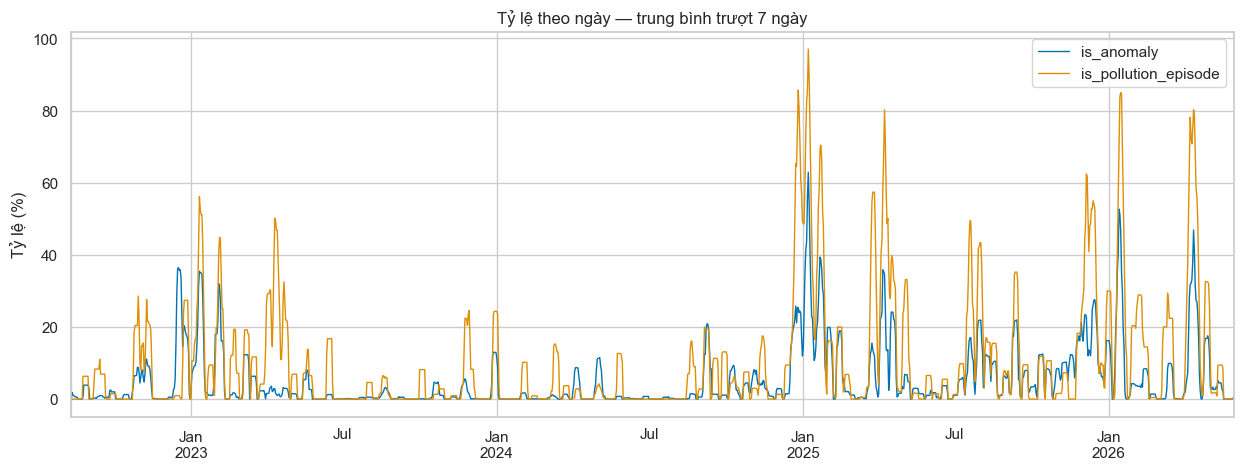

,station_id,location_name,anomaly_rate,pollution_episode_rate,attention_rate
7,HN_THANH_XUAN,Thanh Xuan,7.08,12.35,14.92
1,HN_CAU_GIAY,Cau Giay,6.36,13.07,15.06
0,HN_BA_DINH,Ba Dinh,5.25,9.79,11.99
2,HN_DONG_DA,Dong Da,5.25,9.79,11.99
6,HN_LONG_BIEN,Long Bien,5.15,9.79,11.87
3,HN_HAI_BA_TRUNG,Hai Ba Trung,5.12,9.79,11.89
5,HN_HOAN_KIEM,Hoan Kiem,5.11,9.79,11.88
4,HN_HA_DONG,Ha Dong,3.41,8.80,10.04


In [5]:
daily = (
    results.set_index('timestamp')
    .groupby(pd.Grouper(freq='D'))[['is_anomaly', 'is_pollution_episode']]
    .mean().mul(100)
)
ax = daily.rolling(7, min_periods=1).mean().plot(figsize=(15, 5), linewidth=1)
ax.set(title='Tỷ lệ theo ngày — trung bình trượt 7 ngày', xlabel='', ylabel='Tỷ lệ (%)')
plt.show()

station_summary = results.groupby(['station_id', 'location_name']).agg(
    anomaly_rate=('is_anomaly', lambda values: values.mean() * 100),
    pollution_episode_rate=('is_pollution_episode', lambda values: values.mean() * 100),
    attention_rate=('requires_attention', lambda values: values.mean() * 100),
).reset_index().sort_values('anomaly_rate', ascending=False)
display(station_summary.round(2))

## 5. Các điểm bất thường mạnh nhất

In [6]:
top = (
    results[results['is_anomaly']]
    .nsmallest(20, 'isolation_forest_score')[[
        'split', 'timestamp', 'station_id', 'pm25', 'pm10',
        'pm25_change_1h', 'isolation_forest_score',
        'detection_source', 'anomaly_reason'
    ]]
)
display(top.round(3))

,split,timestamp,station_id,pm25,pm10,pm25_change_1h,isolation_forest_score,detection_source,anomaly_reason
39552,train,2023-03-05 07:00:00+07:00,HN_BA_DINH,203.0,291.5,29.3,-0.715,both,extreme_pm25;multivariate_pattern
39554,train,2023-03-05 07:00:00+07:00,HN_DONG_DA,203.0,291.5,29.3,-0.715,both,extreme_pm25;multivariate_pattern
39557,train,2023-03-05 07:00:00+07:00,HN_HOAN_KIEM,203.0,291.5,29.3,-0.715,both,extreme_pm25;multivariate_pattern
39558,train,2023-03-05 07:00:00+07:00,HN_LONG_BIEN,203.0,291.5,29.3,-0.715,both,extreme_pm25;multivariate_pattern
39555,train,2023-03-05 07:00:00+07:00,HN_HAI_BA_TRUNG,203.0,291.5,29.3,-0.714,both,extreme_pm25;multivariate_pattern
186006,validation,2025-04-06 07:00:00+07:00,HN_LONG_BIEN,228.2,234.7,49.4,-0.710,both,extreme_pm25;multivariate_pattern
186007,validation,2025-04-06 07:00:00+07:00,HN_THANH_XUAN,250.5,257.0,68.0,-0.692,both,extreme_pm25;multivariate_pattern
39566,train,2023-03-05 08:00:00+07:00,HN_LONG_BIEN,197.4,284.1,-5.6,-0.686,isolation_forest,multivariate_pattern
186000,validation,2025-04-06 07:00:00+07:00,HN_BA_DINH,228.2,234.7,49.4,-0.685,both,extreme_pm25;multivariate_pattern
186002,validation,2025-04-06 07:00:00+07:00,HN_DONG_DA,228.2,234.7,49.4,-0.685,both,extreme_pm25;multivariate_pattern


## 6. Kết luận

In [7]:
validation_rate = report['split_summary']['validation']['combined_rate_percent']
test_rate = report['split_summary']['test']['combined_rate_percent']
display(Markdown(f'''
- Combined anomaly rate là **{validation_rate:.2f}%** trên validation và **{test_rate:.2f}%** trên test.
- Isolation Forest đóng góp phần lớn phát hiện; luật cứng cung cấp lý do rõ ràng cho lỗi/spike cực đoan.
- `is_pollution_episode` không bị gộp thành lỗi cảm biến; `requires_attention` mới là cờ tổng hợp cho hệ thống cảnh báo.
- Chưa có ground truth nên không báo accuracy, precision hay recall. Bước cải tiến đúng là chuyên gia gán nhãn một mẫu các điểm bị cờ.
- Artifact inference: `artifacts/models/anomaly_detector.joblib`.
'''))


- Combined anomaly rate là **9.81%** trên validation và **7.88%** trên test.
- Isolation Forest đóng góp phần lớn phát hiện; luật cứng cung cấp lý do rõ ràng cho lỗi/spike cực đoan.
- `is_pollution_episode` không bị gộp thành lỗi cảm biến; `requires_attention` mới là cờ tổng hợp cho hệ thống cảnh báo.
- Chưa có ground truth nên không báo accuracy, precision hay recall. Bước cải tiến đúng là chuyên gia gán nhãn một mẫu các điểm bị cờ.
- Artifact inference: `artifacts/models/anomaly_detector.joblib`.
